# ANÁLISE DE MACHINE LEARNING: Previsão de Sobrevivência no Titanic

**Autor:** Douglas Chaves Moura  
**Metodologia:** Análise Exploratória de Dados (EDA), Feature Engineering, Modelagem em Ensembles (Bagging e Boosting).

Este notebook apresenta uma solução analítica para a clássica competição de *Machine Learning* do Kaggle. O projeto vai muito além da aplicação cega de algoritmos: o objetivo é analisar os dados usando técnicas de **Exploração**, **Tratamento Estatístico (Missing Values, Scaling)** e **Otimização de Hiperparâmetros**.

Avaliaremos três abordagens metodológicas distintas de modelagem:
1. **Regressão Logística** (Modelo Linear Estocástico / Baseline)
2. **Random Forest** (Modelo de Ensemble - Bagging)
3. **XGBoost** (Modelo de Ensemble - Boosting)

## 1. IMPORTAÇÕES

In [2]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

import xgboost as xgb

# Ignorar warnings desnecessários
warnings.filterwarnings('ignore')

## 2. CARREGAMENTO DOS DADOS

In [4]:
# Carregando os dados de treino e teste
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("=== FORMA DOS DATASETS ===")
print(f"Treino: {train_df.shape}")
print(f"Teste: {test_df.shape}")

train_df.head()

=== FORMA DOS DATASETS ===
Treino: (891, 12)
Teste: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

In [5]:
# 1. Preparação dos Dados: Cálculo de frequências e renomeação de categorias para o plot
surv_counts = train_df['Survived'].value_counts().reset_index()
surv_counts.columns = ['Survived', 'Count']
surv_counts['Survived'] = surv_counts['Survived'].map({0: 'Não Sobreviveu', 1: 'Sobreviveu'})

# 2. Criação da Figura: Gráfico de barras com mapeamento de cores personalizadas
fig_surv = px.bar(surv_counts, x='Survived', y='Count', 
                  title="Distribuição de Sobreviventes (Target)",
                  color='Survived',
                  color_discrete_map={'Não Sobreviveu': '#5E7E99', 'Sobreviveu': '#D4AF37'})

# 3. Rótulos e Interação: Formatação dos valores sobre as barras e do tooltip (hover)
fig_surv.update_traces(
    textposition="outside",
    texttemplate="%{y:,.0f}",
    hovertemplate="<b>%{x}</b><br>Quantidade: %{y:,.0f} passageiros<extra></extra>"
)

# 4. Estilização do Layout: Aplicação do tema escuro, tipografia e ajustes de eixo
fig_surv.update_layout(
    separators=",.",
    title=dict(x=0.5, font=dict(size=22, family="Arial", color="#E2E8F0")),
    xaxis_title="",
    yaxis_title="Quantidade de Passageiros",
    font=dict(family="Arial", size=14, color="#E2E8F0"),
    plot_bgcolor='#0B1320',
    paper_bgcolor='#0B1320',
    showlegend=False, # Legenda desativada pois o eixo X já identifica as classes
    xaxis=dict(showgrid=False, color="#E2E8F0"),
    yaxis=dict(showgrid=True, gridcolor="#1E293B", color="#E2E8F0", range=[0, surv_counts['Count'].max() * 1.20])
)

fig_surv.show()

### Interpretação: Desbalanceamento de Classes (Variável Target)

> **Insight:** Observamos um claro desbalanceamento na variável alvo (`Survived`). Cerca de 60% dos passageiros registrados neste conjunto de treinamento não sobreviveram ao naufrágio. O desbalanceamento exigirá cautela ao analisarmos métricas: em casos assim, focar apenas na **Acurácia** pode ser ilusório; métricas como **Precision**, **Recall** e **F1-Score** fornecerão uma avaliação de desempenho mais honesta.

In [6]:
# 1. Preparação dos Dados: Criação de cópia isolada e mapeamento da variável alvo (Target) para texto explicativo
plot_df = train_df.copy()
plot_df['Status'] = plot_df['Survived'].map({0: 'Não Sobreviveu', 1: 'Sobreviveu'})

# 2. Criação da Figura: Histograma agrupado que faz a contagem automática por gênero e status
fig_sex = px.histogram(plot_df, x='Sex', color='Status', 
                 title="Taxa de Sobrevivência por Gênero", barmode='group',
                 color_discrete_map={'Não Sobreviveu': '#5E7E99', 'Sobreviveu': '#D4AF37'})

# 3. Rótulos e Interação: Configuração da formatação numérica sobre as barras e customização do tooltip (hover)
fig_sex.update_traces(
    textposition="outside",
    texttemplate="%{y:,.0f}",
    hovertemplate="<b>Gênero: %{x}</b><br>Status: %{data.name}<br>Quantidade: %{y:,.0f} passageiros<extra></extra>"
)

# 4. Escala Dinâmica: Cálculo da frequência máxima agrupada para garantir o dimensionamento correto do gráfico
max_count_sex = plot_df.groupby(["Sex", "Status"]).size().max()

# 5. Estilização do Layout: Aplicação do dark theme, formatação da legenda e ajuste de folga no eixo Y (15%)
fig_sex.update_layout(
    separators=",.",
    title=dict(x=0.5, font=dict(size=22, family="Arial", color="#E2E8F0")),
    xaxis_title="Gênero",
    yaxis_title="Quantidade de Passageiros",
    font=dict(family="Arial", size=14, color="#E2E8F0"),
    plot_bgcolor='#0B1320',
    paper_bgcolor='#0B1320',
    legend_title_font_color="#E2E8F0",
    legend_font_color="#E2E8F0",
    xaxis=dict(showgrid=False, color="#E2E8F0"),
    yaxis=dict(
        showgrid=True, 
        gridcolor="#1E293B", 
        color="#E2E8F0",
        range=[0, max_count_sex * 1.15]
    )
)

fig_sex.show()

### Interpretação: Taxa de Sobrevivência por Sexo

> **Insight:** A visualização reforça de maneira contundente que a diretriz histórica do "mulheres e crianças primeiro" foi de fato aplicada durante o naufrágio. A probabilidade condicional de sobrevivência de uma mulher a bordo era significativamente superior à probabilidade de sobrevivência de um homem.

In [7]:
# 1. Preparação dos Dados: Criação de cópia e tradução das variáveis alvo e preditora para rótulos descritivos
plot_df_class = train_df.copy()
plot_df_class['Status'] = plot_df_class['Survived'].map({0: 'Não Sobreviveu', 1: 'Sobreviveu'})

plot_df_class['Classe_Nome'] = plot_df_class['Pclass'].map({
    1: 'Alta', 
    2: 'Média', 
    3: 'Baixa'
})

# 2. Criação da Figura: Histograma com cores customizadas e ordenação lógica forçada do eixo X (Baixa -> Média -> Alta)
fig_pclass = px.histogram(plot_df_class, x='Classe_Nome', color='Status', 
                    title="Taxa de Sobrevivência por Classe do Bilhete", barmode='group',
                    color_discrete_map={'Não Sobreviveu': '#5E7E99', 'Sobreviveu': '#D4AF37'},
                    category_orders={"Classe_Nome": ["Baixa", "Média", "Alta"]})

# 3. Rótulos e Interação: Formatação dos números sobre as barras e customização do tooltip (hover)
fig_pclass.update_traces(
    textposition="outside",
    texttemplate="%{y:,.0f}",
    hovertemplate="<b>Classe %{x}</b><br>Status: %{data.name}<br>Quantidade: %{y:,.0f} passageiros<extra></extra>"
)

# 4. Escala Dinâmica: Descoberta da barra mais alta para evitar cortes visuais no layout final
max_count_class = plot_df_class.groupby(['Classe_Nome', 'Status']).size().max()

# 5. Estilização do Layout: Aplicação do dark theme, formatação da legenda e margem extra no eixo Y (15%)
fig_pclass.update_layout(
    separators=",.",
    title=dict(x=0.5, font=dict(size=22, family="Arial", color="#E2E8F0")),
    xaxis_title="Classe",
    yaxis_title="Quantidade de Passageiros",
    font=dict(family="Arial", size=14, color="#E2E8F0"),
    plot_bgcolor='#0B1320',
    paper_bgcolor='#0B1320',
    legend_title_font_color="#E2E8F0",
    legend_font_color="#E2E8F0",
    xaxis=dict(showgrid=False, color="#E2E8F0", tickmode='linear'),
    yaxis=dict(showgrid=True, gridcolor="#1E293B", color="#E2E8F0", range=[0, max_count_class * 1.15])
)

fig_pclass.show()

### Interpretação: Status Socioeconômico (Classe do Bilhete)

> **Insight:** Existe uma clara desigualdade nas taxas de sobrevivência relacionada ao status socioeconômico (*Pclass*). Passageiros da 1ª classe apresentaram as maiores taxas de sobrevivência. Na 3ª classe (que concentrava a maioria dos passageiros), a grande maioria não sobreviveu, indicando que a proximidade física aos botes e o favorecimento explícito ditaram as chances de sucesso no resgate.

### 3.4. Sobrevivência por Faixa Etária

In [8]:
# 1. Feature Engineering (Engenharia de Atributos): Discretização da variável contínua 'Age' em categorias lógicas
bins = [0, 12, 24, 59, 100]
labels = ['Crianças (0-12)', 'Jovens (13-24)', 'Adultos (25-59)', 'Idosos (60+)']
train_df['Faixa_Etaria'] = pd.cut(train_df['Age'], bins=bins, labels=labels)

# 2. Preparação dos Dados: Agrupamento e contagem para otimização do plot, seguido do mapeamento da variável Target
age_surv = train_df.groupby(['Faixa_Etaria', 'Survived'], observed=True).size().reset_index(name='Count')
age_surv['Survived'] = age_surv['Survived'].map({0: 'Não Sobreviveu', 1: 'Sobreviveu'})

# 3. Criação da Figura: Gráfico de barras agrupado mantendo a paleta de cores padronizada do projeto
fig_age = px.bar(age_surv, x='Faixa_Etaria', y='Count', color='Survived', 
                 barmode='group', title="Sobrevivência por Faixa Etária",
                 color_discrete_map={'Não Sobreviveu': '#5E7E99', 'Sobreviveu': '#D4AF37'})

# 4. Rótulos e Interação: Exibição de valores literais sobre as barras e customização do tooltip contextual (hover)
fig_age.update_traces(
    textposition="outside",
    texttemplate="%{y:,.0f}",
    hovertemplate="<b>Faixa Etária: %{x}</b><br>Status: %{data.name}<br>Quantidade: %{y:,.0f} passageiros<extra></extra>"
)

# 5. Escala Dinâmica: Identificação da contagem máxima para evitar cortes visuais no limite superior do gráfico
max_count_age = age_surv['Count'].max()

# 6. Estilização do Layout: Aplicação do dark theme, customização tipográfica e ajuste de folga no eixo Y (15%)
fig_age.update_layout(
    separators=",.",
    title=dict(x=0.5, font=dict(size=22, family="Arial", color="#E2E8F0"), pad=dict(b=15)),
    margin=dict(t=90), 
    xaxis_title="", 
    yaxis_title="Quantidade de Passageiros",
    font=dict(family="Arial", size=14, color="#E2E8F0"),
    plot_bgcolor='#0B1320',
    paper_bgcolor='#0B1320',
    legend_title_text="Status",
    legend_title_font_color="#E2E8F0",
    legend_font_color="#E2E8F0",
    xaxis=dict(showgrid=False, color="#E2E8F0"),
    yaxis=dict(
        showgrid=True, 
        gridcolor="#1E293B", 
        color="#E2E8F0",
        range=[0, max_count_age * 1.15]
    )
)

fig_age.show()

# 7. Prevenção de Data Leakage e Limpeza: Remoção da feature textual temporária para garantir a compatibilidade com algoritmos de Machine Learning
train_df.drop(columns=['Faixa_Etaria'], inplace=True)

### Interpretação: Taxa de Sobrevivência por Faixa Etária

> **Insight:** Observando as faixas etárias, o grupo das crianças (0-12 anos) é o único onde a barra de "Sobreviveu" supera visivelmente a de "Não Sobreviveu". Adultos e jovens tiveram as maiores baixas absolutas, confirmando que a prioridade de evacuação foi rigidamente mantida para os mais jovens.

### 3.5. Nuvem de Palavras: Sobrenomes dos Passageiros

A *Word Cloud* (Nuvem de Palavras) abaixo destaca a frequência dos sobrenomes das famílias que embarcaram. Fontes maiores indicam uma maior incidência daquele núcleo familiar a bordo (como "Andersson", "Sage" e "Goodwin"). Em tragédias históricas, grandes grupos familiares frequentemente enfrentaram maiores dificuldades de coordenação na evacuação.

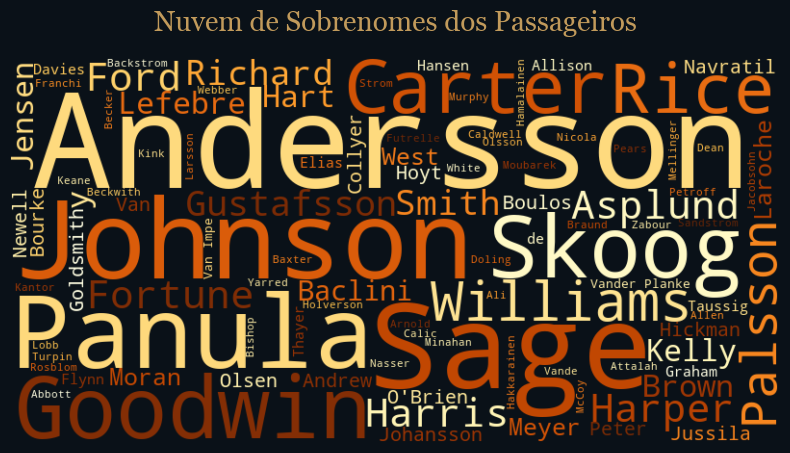

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Extração dos sobrenomes
# O formato do nome no dataset é "Sobrenome, Titulo. Nomes"
train_df['Surname'] = train_df['Name'].apply(lambda x: x.split(',')[0].strip())

# Criando string única com todos os sobrenomes
text = " ".join(train_df['Surname'].tolist())

# Configurando e gerando a nuvem de palavras com as cores do tema
wordcloud = WordCloud(width=800, height=400, 
                      background_color='#0A1118', 
                      colormap='YlOrBr', 
                      max_words=100, 
                      contour_width=0).generate(text)

# Plotando
plt.figure(figsize=(10, 5), facecolor='#0A1118') # Fundo externo
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Nuvem de Sobrenomes dos Passageiros", color="#C19A5B", fontsize=20, fontname='Georgia', pad=20)
plt.show()